# Instructions to follow

- Each student may use 2 separate SDRs in the same computer for end-to-end communication.
- Connect both SDRs to the computer and ensure that their ip addresses are different. 192.168.2.1 and 192.168.3.1
- If ip addresses are same, change one SDR's ip address by editing the config file in file manager. Change in both ipaddr and ipaddr_host.


- Use separate notebooks for transmitter code and receiver code, to  avoid long scrolling on the screen.
- After code of each block, print each variables you coded to see and observe, but print only few points
- Example:  message_bits[:100], bpsk_signal[:100], zero_padded_sequence[:100], pulse_shaped_signal[:100],rx_samples[:100], decoded_bits[:100], etc.,

- Plot each signal you coded and computed after every block
- While plotting plot only few samples, other wise you cannot see the structure of the signal
- rx-signal inlcude 1,00,000 data points, so when plotted all the points you cannot see the signal at all, instead you see only a thick harizontal bar.
- Observe in the below image, difference when you plot all the points and when plotted only few data points


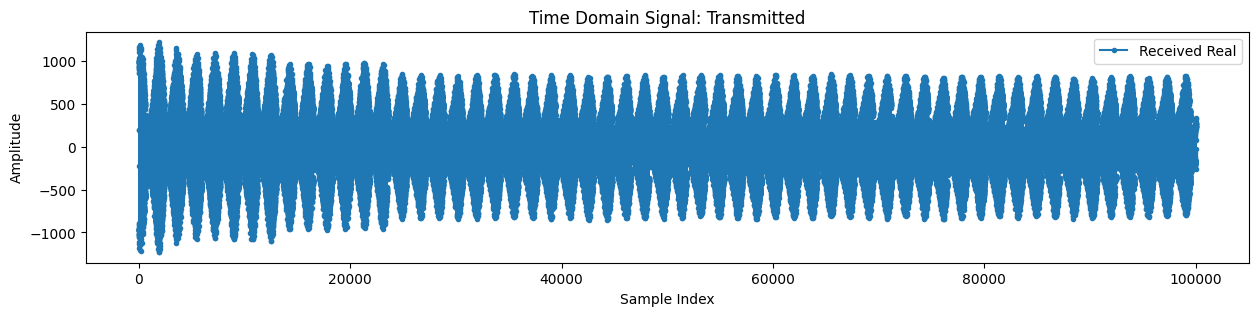


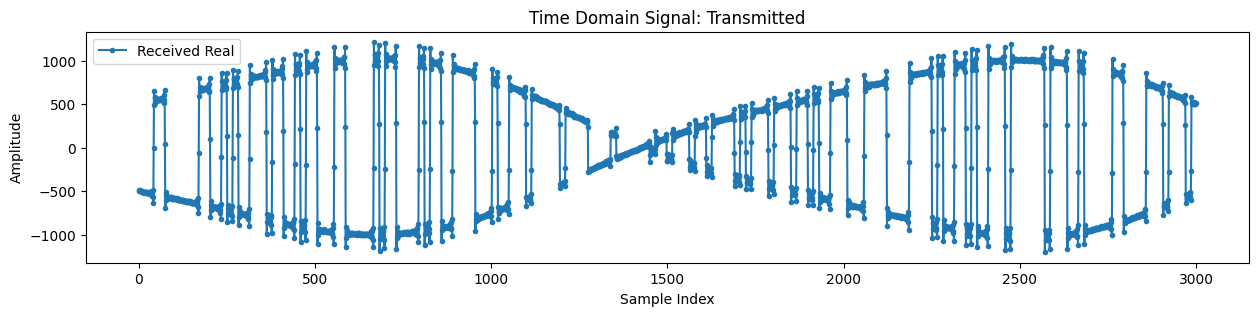


- If you correctly receiving signal, you will see signal as above, means signal with high amplitude (more than 1000).
- Sometimes you will see the signal like below image. That is not received signal, it is only noise signal.
- Your transmitter might stopped transmitting, check and retransmit and receive again.

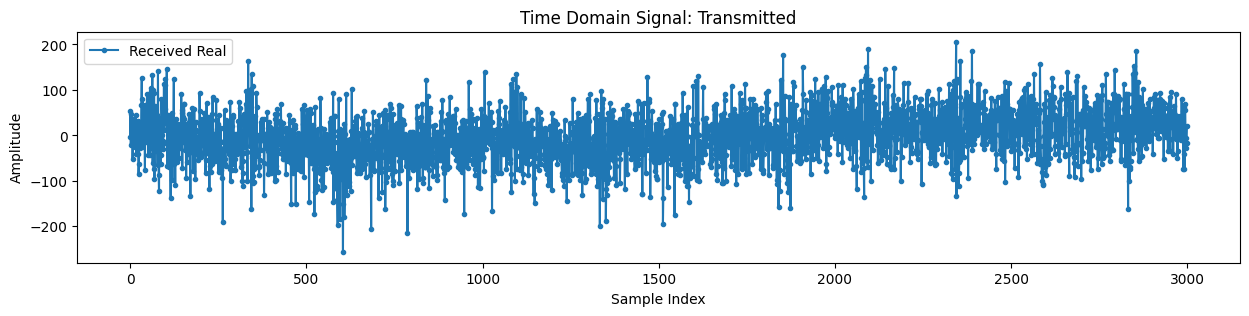

- As of now, we using BPSK signal, no imaginary signal. Hence, plot only real signal, do not plot imaginary signal, which is not usefull for observation.

- Plot scatter plot complex signal (imaginary signal is helpful here) after every block.


- Use the following code to plot PSD of any signal.

```python
fs = sample_rate
psd = np.fft.fftshift(np.abs(np.fft.fft(signal)))
f = np.linspace(-fs/2.0, fs/2.0, len(psd))
# Plotting
plt.figure(figsize=(4, 3))
plt.plot(f/1e6, psd)
plt.xlabel('f in Mhz')
plt.xlim(-0.03, 0.03)  # Adjust this to limit the x axis range and to zoom the plot
plt.show()
```

- Your PSD graph look like this for squared signal

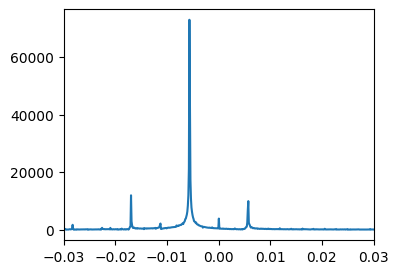

- Note the number message bits at the transmitter code, while decoding use the same to collect that many number of bits
- i.e. number of decoded_bits =  number of message_bits
- Use decoded_bits for source decoding, converting message_text again.

## Import Requied Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import adi

# <font color="blue"> RECEIVER </font>



## <font color="blue"> If you are receiving perform the below tasks

## <font color="blue"> Task 1: Receive signal using SDR

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import adi

# From PySDR
sample_rate = 1e6 # Hz
center_freq = ______e6 # Hz  (Select same carrier frequency used
                            # for transmission to receive the signal)
num_samps = 1000000 # number of samples per call to rx()

sdr2 = adi.Pluto("ip:192.168.3.1")
sdr2.sample_rate = int(sample_rate)

sdr2.rx_lo = int(center_freq)
sdr2.rx_rf_bandwidth = int(sample_rate)
sdr2.rx_buffer_size = num_samps

# sdr2.gain_control_mode_chan0 = 'manual'
# sdr2.rx_hardwaregain_chan0 = 70 # dB, increase to increase the receive gain, but be careful not to saturate the ADC

sdr2.gain_control_mode_chan0 = 'slow_attack'

# Receive samples
rx_samples = sdr2.rx()
print('received samples \n', rx_samples)

### Plot the received signal

In [ ]:
# Write your code here



### Plot scatter-plot of received signal

In [ ]:
# write your code here



## Task 1a: Matched Filtering

- Do matched filtering before normalization

In [ ]:
# Write your code here




## <font color="blue"> Task 2: Normalize the Received signal </font>

- Normalize the received signal in range -1 to +1

- Compute magnitudes of the received signal, magnitude  = absolute of received signal

- Normalized signal = Received signal / magnitudes

In [ ]:
# Write your code here

magnitudes =

norm_rx_signal =


### Plot normalized signal

In [ ]:
# Write your code




### Plot scatter-plot of normalized signal

In [ ]:
# Write your code here




## <font color="blue"> Task 3: Coarse Frequency Synchronization </font>

- Refer: https://pysdr.org/content/sync.html - section - Coarse Frequency Synchronization

- Even though we tell the transmitter and receiver to operate on the same center frequency, there is going to be a slight frequency offset between the two due to either imperfections in hardware (e.g., the oscillator) or a Doppler shift from movement. This frequency offset will be tiny relative to the carrier frequency, but even a small offset can throw off a digital signal

- Frequency synchronization is usually broken down into coarse sync and fine sync, where coarse corrects large offsets on the order of kHz or more, while the fine sync corrects whatever is left.

- In order to perform coarse frequency offset estimation (if we can estimate the offset frequency, then we can undo it), is to take the square of our signal.

- $r^2(t) = s^2(t) e^{j4 \pi f_0 t}$

- A simple method for figuring out
 is to take the FFT of the signal after we square it N times and seeing where the spike occurs

 - Actually correcting this frequency offset is multiplying by a complex exponential, except with a negative sign since we want to remove the offset.

In [ ]:


squared_signal = norm_rx_signal**2. # run this code



### Plot the psd of the squared_signal

In [ ]:
### Write tour code here



### Find the frequency where maximum psd value occurs


In [ ]:
# run this code

fs = sample_rate

f = np.linspace(-fs/2.0, fs/2.0, len(psd))

max_freq = f[np.argmax(psd)]

### Coarse correction

- $r^2(t)e^{-j2\pi\frac{(maxfreq)}{2} t}$


In [ ]:
# run this code

Ts = 1/fs # calc sample period

t = np.arange(0, Ts*len(norm_rx_signal), Ts) # create time vector

coarse_corrected = norm_rx_signal * np.exp(-1j*2*np.pi*max_freq*t/2.0)

### Plot the coarse corrected signal

In [ ]:
### Write your code here



### Plot scatter-plot of coarse corrected signal

In [ ]:
# Write your code here



## <font color="blue"> Task 4:  Do Downsampling </font>

- Downsample the coarse_corrected signal

-  Downsampling factor = sps = 16

In [ ]:
sps = 16 # downsampling factor
downsamplig_factor = sps
# Write your code here

down_sampled_signal =

### Plot the downsampled signal

In [ ]:
# write your code here



### Plot scatter-plot of downsampled signal

In [ ]:
# write your code here



## Task 4a: Time Synchronization

Replace Downsampling code with time sync code

In [ ]:
# Write your code here



## <font color="blue"> Task 5: Fine frequency Synchronization </font>

- Refer:  https://pysdr.org/content/sync.html -- section - Fine Frequency Synchronization

### Use the following code

In [ ]:
# run this code

samples = down_sampled_signal

# Parameters
N = len(samples)
phase = 0
freq = 0
alpha = 0.132
beta = 0.00932

# Costas Loop
fine_correct = np.zeros(N, dtype=np.complex64)
freq_log = []
for i in range(N):
    fine_correct[i] = samples[i] * np.exp(-1j*phase)
    error = np.real(fine_correct[i]) * np.imag(fine_correct[i])
    freq += (beta * error)
    freq_log.append(freq * fs / (2*np.pi))
    phase += freq + (alpha * error)
    while phase >= 2*np.pi:
        phase -= 2*np.pi
    while phase < 0:
        phase += 2*np.pi

#############################
fine_corrected = fine_correct
##############################


# Plot correction status over number of samples
plt.figure(figsize=(5, 3))
plt.plot(freq_log,'.-')
plt.show()

### Plot the fine corrected signal

In [ ]:
# write your code here



### Plot scatter-plot of fine corrected signal

In [ ]:
# Write your code here



## <font color="blue"> Task 6: Frame Synchronization

### Compute cross-correlation output

-  Cross correlate the fine_corrected with barker code, use mode = 'full'

In [ ]:
correlation_output =  # Write your code here



### Plot the correlation output

In [ ]:
# write your code here



### Find the starting index of original BPSK

- starting index = arg max of ( absolute value of correlation output ) + 1

In [ ]:
start_index = # Write your code here



### Rotate the fine corrected signal if maximum (peak) of correlation output is negative

- Why ? think.

- Use the following code.

In [ ]:
# run this code
peak = np.real(correlation_output)[start_index-1]
if peak < 0:
    fine_correct = -1*fine_correct


### Collect samples starting from start_index

 -  Use n_bits (numbers of samples to collect) = 52

 - 52 = number of message bits

 - Receiver cannot know this, unless TX and RX agreed for fixed number of bits transmission and reception each time, this fixed number is called payload size.

 - You will learn more about this later.

In [ ]:
n_bits =   # Know by your adjacent transmitting partner

fr_sync_op = fine_correct[start_index:start_index+n_bits]

### Plot scatter-plot frame syanchronization output

In [ ]:
# scatter plot of fr_sync_op

# Write your code here



## <font color="blue"> Task 7: Demodulation </font>

- Do the reverse of BPSK modulation

- Map to bit 0 if symbol is -1, map to bit 1 if symbol is +1.


In [ ]:
# Demodulate the fr_sync_op

# Wtite your code here

recovered_bits =

## <font color="blue"> Task 8: Decode Recovered to Text </font>

- Divide the recovered_bits array into chunks of 7 bits each.

- Convert each 7-bit chunk into its corresponding ASCII decimal number.

- Map each ASCII number to its equivalent text character.

- Join all characters together to form the decoded text message.

- Compare the decoded message with transmitte message (know this by your adjacent transmitter.)

In [ ]:
# write your code here

final_decoded_message =


###